In [1]:
from pathlib import Path
import xmltodict
import pandas as pd
import numpy as np
import tifffile as tiff
import xmltodict
from dateutil import parser
import re

import matplotlib.pyplot as plt
from collections import namedtuple
from shapely.geometry import box

from skimage.registration import phase_cross_correlation
from skimage.transform import rescale, resize, downscale_local_mean
from skimage import exposure

import zarr
from pylibCZIrw import czi as pyczi

In [6]:
from atlas.io import extract_s_number
from atlas.io import reorder_files_by_s_number, parse_shorthand_order
from atlas.alignment import initialize_alignment_df_points, get_matched_points_by_quadrant
from atlas.alignment import estimate_alignment_transform, compute_cumulative_transforms, compute_canvas_from_df, print_similarity_parameters

series_folder = Path(r"E:\PROJECTS\EM\LUKE\TA30\test")
series_folder = Path(r"E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_data\alignment_test")
series_folder = Path(r"E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_data\session_1115605826\Site 2")
series_folder = Path(r"E:\PROJECTS\EM\Alma\plant4-wafer-1\alma-plant-4_data\session_1084385689\Site 1") # plant 4 is sample 1
series_folder = Path(r"E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_data\alignment_test_3")

tif_list = []
for folder in series_folder.iterdir():  # Iterate over all items in the folder
    if folder.is_file() and folder.name.endswith(".tiff"):
        #print(f"fould series image: {folder.name}")
        tif_list.append(folder)

tif_list_sorted = sorted(tif_list, key=extract_s_number)

correct_order_path = Path(series_folder.joinpath("correct_order.txt"))

try:
    new_order = parse_shorthand_order(correct_order_path)
    print(f"Loaded correct_order.txt: {new_order}")

    tif_list_sorted = reorder_files_by_s_number(tif_list_sorted, new_order)
    print("Files reordered based on correct_order.txt:")
    for f in tif_list_sorted:
        print(f)

except FileNotFoundError:
    print("No correct_order.txt found — using original order.")
except Exception as e:
    print(f"Error reading or applying correct_order.txt: {e}")

down_scale = 10

# initialize the dataframe, in particular we asign the pair-wise patching of the images
# based on the sorted list of tiff.
z_align_df = initialize_alignment_df_points(tif_list_sorted, down_scale)

z_align_df

No correct_order.txt found — using original order.


,moving_path,reference_path,moving_shape,reference_shape,moving_points,reference_points,image_transform,cumulative_transform,image_transform_ds,cumulative_transform_ds,down_scale
0,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,None,None,None,None,None,None,None,None,10
1,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,None,None,None,None,None,None,None,None,10
2,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,None,None,None,None,None,None,None,None,10
3,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,None,None,None,None,None,None,None,None,10
4,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,None,None,None,None,None,None,None,None,10


Processing index 1:
  Moving: stitched_image_S_2.tiff
  Reference: stitched_image_S_1.tiff
the shift for quadrant was: [10. 10.]
ref origin: [0 0]
the shift for quadrant was: [10. 10.]
ref origin: [0 0]


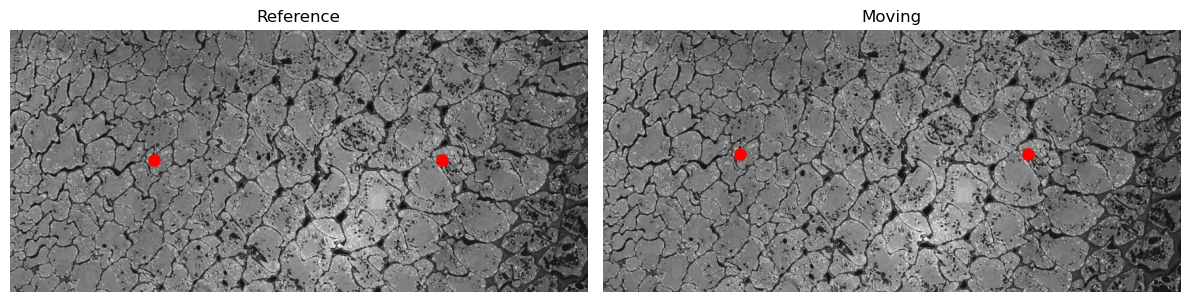

In [7]:
# example of one iteration, and figure
index = 1

n_rows = 1
n_cols = 2

row = z_align_df.iloc[index]

mov_path = row["moving_path"]
ref_path = row["reference_path"]
down_scale = int(row["down_scale"])

print(f"Processing index {index}:\n  Moving: {mov_path.name}\n  Reference: {ref_path.name}")

# Load full-res images
mov_img = tiff.imread(mov_path)
ref_img = tiff.imread(ref_path)

# ✅ Store original shapes before downscaling
z_align_df.at[index, "moving_shape"] = mov_img.shape
z_align_df.at[index, "reference_shape"] = ref_img.shape

# ✅ Downscale for performance optimization
mov_img_ds = downscale_local_mean(mov_img, (down_scale, down_scale)).astype(mov_img.dtype)
ref_img_ds = downscale_local_mean(ref_img, (down_scale, down_scale)).astype(ref_img.dtype)

# Get matched points
ref_pts_ds, mov_pts_ds = get_matched_points_by_quadrant(ref_img_ds, mov_img_ds, rows=n_rows, cols=n_cols)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# --- Reference image ---
axes[0].imshow(ref_img_ds,
               cmap='gray',
               vmin=ref_img_ds.min(),
               vmax=ref_img_ds.max())
axes[0].set_title("Reference")
axes[0].axis("off")

for x, y in ref_pts_ds:
    axes[0].plot(y, x, 'ro', markersize=8)


# --- Moving image ---
axes[1].imshow(mov_img_ds,
               cmap='gray',
               vmin=mov_img_ds.min(),
               vmax=mov_img_ds.max())
axes[1].set_title("Moving")
axes[1].axis("off")

for x, y in mov_pts_ds:
    axes[1].plot(y, x, 'ro', markersize=8)


plt.tight_layout()
plt.show()

In [8]:
# run alignment
n_rows = 2
n_cols = 1

tmodel_transform = "translation" # translation only
#tmodel_transform = "euclidean" # translation rotation, no scaling
#tmodel_transform = "similarity"
for index, row in z_align_df.iterrows():
    mov_path = row["moving_path"]
    ref_path = row["reference_path"]
    down_scale = int(row["down_scale"])

    print(f"Processing index {index}:\n  Moving: {mov_path.name}\n  Reference: {ref_path.name}")

    # Load full-res images
    mov_img = tiff.imread(mov_path)
    ref_img = tiff.imread(ref_path)

    # ✅ Store original shapes before downscaling
    z_align_df.at[index, "moving_shape"] = mov_img.shape
    z_align_df.at[index, "reference_shape"] = ref_img.shape

    # ✅ Downscale for performance optimization
    mov_img_ds = downscale_local_mean(mov_img, (down_scale, down_scale)).astype(mov_img.dtype)
    ref_img_ds = downscale_local_mean(ref_img, (down_scale, down_scale)).astype(ref_img.dtype)

    # Get matched points
    ref_pts_ds, mov_pts_ds = get_matched_points_by_quadrant(ref_img_ds, mov_img_ds, rows=n_rows, cols=n_cols)
    
    # Estimate transform ds
    tform_ds = estimate_alignment_transform(ref_pts_ds, mov_pts_ds, model=tmodel_transform)

    # 🔁 Upscale points back to original resolution
    ref_pts = np.array(ref_pts_ds) * down_scale
    mov_pts = np.array(mov_pts_ds) * down_scale
    # Estimate transform
    tform = estimate_alignment_transform(ref_pts, mov_pts, model=tmodel_transform)

    # Store results in DataFrame
    z_align_df.at[index, "reference_points"] = ref_pts
    z_align_df.at[index, "moving_points"] = mov_pts
    z_align_df.at[index, "image_transform"] = tform

    z_align_df.at[index, "image_transform_ds"] = tform_ds

    print_similarity_parameters(tform)
    print()

compute_cumulative_transforms(z_align_df, transform_col="image_transform", output_col="cumulative_transform")
compute_cumulative_transforms(z_align_df, transform_col="image_transform_ds", output_col="cumulative_transform_ds")

# Compute canvas shape and offset for downsampled alignment
canvas_shape, offset = compute_canvas_from_df(z_align_df, transform_column="cumulative_transform_ds")

z_align_df


Processing index 0:
  Moving: stitched_image_S_1.tiff
  Reference: stitched_image_S_1.tiff
the shift for quadrant was: [0. 0.]
ref origin: [0 0]
the shift for quadrant was: [0. 0.]
ref origin: [0 0]
checking!!!!!!
checking!!!!!!
Estimated transform parameters:
  Translation: x = 0.00, y = 0.00
  Rotation: 0.00 degrees
  Scale: 1.00000

Processing index 1:
  Moving: stitched_image_S_2.tiff
  Reference: stitched_image_S_1.tiff
the shift for quadrant was: [10. 10.]
ref origin: [0 0]
the shift for quadrant was: [10. 10.]
ref origin: [0 0]
checking!!!!!!
checking!!!!!!
Estimated transform parameters:
  Translation: x = 100.00, y = 100.00
  Rotation: 0.00 degrees
  Scale: 1.00000

Processing index 2:
  Moving: stitched_image_S_3.tiff
  Reference: stitched_image_S_2.tiff
the shift for quadrant was: [-20.   0.]
ref origin: [0 0]
the shift for quadrant was: [-20.   0.]
ref origin: [0 0]
checking!!!!!!
checking!!!!!!
Estimated transform parameters:
  Translation: x = 0.00, y = -200.00
  Rotation

,moving_path,reference_path,moving_shape,reference_shape,moving_points,reference_points,image_transform,cumulative_transform,image_transform_ds,cumulative_transform_ds,down_scale
0,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,"(4000, 8800)","(4000, 8800)","[[990.0, 4390.0], [2985.0, 4390.0]]","[[990.0, 4390.0], [2985.0, 4390.0]]","<SimilarityTransform(matrix=\n [[ 1., -0., ...","<SimilarityTransform(matrix=\n [[ 1., -0., ...","<SimilarityTransform(matrix=\n [[ 1., -0., ...","<SimilarityTransform(matrix=\n [[ 1., -0., ...",10
1,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,"(4000, 8800)","(4000, 8800)","[[890.0, 4290.0], [2885.0, 4290.0]]","[[990.0, 4390.0], [2985.0, 4390.0]]","<SimilarityTransform(matrix=\n [[ 1., -0....","<SimilarityTransform(matrix=\n [[ 1., 0....","<SimilarityTransform(matrix=\n [[ 1., -0., ...","<SimilarityTransform(matrix=\n [[ 1., 0., ...",10
2,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,"(4000, 8800)","(4000, 8800)","[[1190.0, 4390.0], [3185.0, 4390.0]]","[[990.0, 4390.0], [2985.0, 4390.0]]","<SimilarityTransform(matrix=\n [[ 1., -...","<SimilarityTransform(matrix=\n [[ 1., ...","<SimilarityTransform(matrix=\n [[ 1., -0....","<SimilarityTransform(matrix=\n [[ 1., 0....",10
3,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,"(4000, 8800)","(4000, 8800)","[[790.0, 4590.0], [2785.0, 4590.0]]","[[990.0, 4390.0], [2985.0, 4390.0]]","<SimilarityTransform(matrix=\n [[ 1., -...","<SimilarityTransform(matrix=\n [[ 1., ...","<SimilarityTransform(matrix=\n [[ 1., -0....","<SimilarityTransform(matrix=\n [[ 1., 0....",10
4,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,E:\PROJECTS\EM\Alma\plant2-wafer-1\plant 2_dat...,"(4000, 8800)","(4000, 8800)","[[1190.0, 4390.0], [3185.0, 4390.0]]","[[990.0, 4390.0], [2985.0, 4390.0]]","<SimilarityTransform(matrix=\n [[ 1., -...","<SimilarityTransform(matrix=\n [[ 1., ...","<SimilarityTransform(matrix=\n [[ 1., -0....","<SimilarityTransform(matrix=\n [[ 1., 0....",10


In [9]:
from skimage.transform import warp

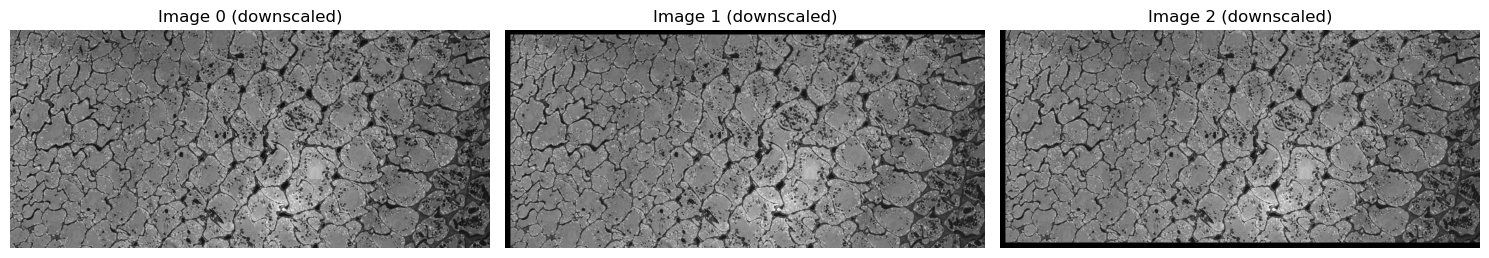

In [10]:
from skimage.transform import downscale_local_mean
import matplotlib.pyplot as plt
import tifffile as tiff

# Choose mode: "full" or "downscaled"
mode = "downscaled"  # or "full"

# Automatically select transform column based on mode
transform_column = "cumulative_transform_ds" if mode == "downscaled" else "cumulative_transform"

# Fetch downscale factor (assumes same for all rows)
down_scale = int(z_align_df["down_scale"].iloc[0])

# Prepare list to store images
images = []

# Loop over first 3 images
for i in range(3):
    d=0
    img = tiff.imread(z_align_df["moving_path"][i+d])
    tform = z_align_df[transform_column][i+d]

    if mode == "downscaled":
        img = downscale_local_mean(img, (down_scale, down_scale)).astype(img.dtype)

    warped = warp(img, inverse_map=tform.inverse, output_shape=img.shape, preserve_range=True)
    images.append(warped)

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, img, title in zip(axes, images, ["Image 0", "Image 1", "Image 2"]):
    ax.imshow(img, cmap='gray', vmin=img.min(), vmax=img.max())
    ax.set_title(f"{title} ({mode})")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [11]:
# Find the first CSV file that starts with "PhaseCC_stitching_S_"
csv_file = next(series_folder.glob("PhaseCC_stitching_S_*.csv"), None)

if csv_file is None:
    raise FileNotFoundError("No matching CSV file found in the folder.")

print(f"Found CSV file: {csv_file.name}")

# Load the CSV into a DataFrame
df = pd.read_csv(csv_file)

# Try to find a 'pixelSize' column or entry
if 'PixelSizeMicron' in df.columns:
    pix_size_micron =  df['PixelSizeMicron'].max()
else:
    raise ValueError("No 'pixelSize' parameter found in the CSV.")

print(f"pixel_size in microns {pix_size_micron}")


#TODO: important change this to metadata readout
pixel_size = {
    'Value': pix_size_micron,
    'Axial': 0.200,
    'Unit': 'µm'
}

Found CSV file: phaseCC_stitching_S_1.csv
pixel_size in microns 0.0200251038444286


In [13]:
from skimage.transform import SimilarityTransform

pix_x = pixel_size['Value']
pix_y = pixel_size['Value']
pix_z = pixel_size['Axial']

newczi = Path("test.czi")
print(f"Saving CZI file to: {newczi}")

# Compute canvas shape and offset for downsampled alignment
canvas_shape, offset = compute_canvas_from_df(z_align_df, transform_column="cumulative_transform_ds")

# Create the offset transform that places all images into positive space
offset_tform = SimilarityTransform(translation=(offset)[::-1])  # (y,x) → (x,y)

    
with pyczi.create_czi(newczi, exist_ok=True) as czidoc_w:
    # Loop over Z-planes and channels
    for frame, row in z_align_df.iterrows():
        print(f"Processing frame {frame}")
        img_path = row["moving_path"]
        tform = row["cumulative_transform_ds"]
        

        # Load and downscale the image
        img = tiff.imread(img_path)
        down_scale = int(row["down_scale"])
        img_ds = downscale_local_mean(img, (down_scale, down_scale)).astype(img.dtype)

        # Compose transform to include offset into the common canvas
        full_tform = tform + offset_tform

        # Warp into the common canvas
        tmp_plane = warp(img_ds, inverse_map=full_tform.inverse, output_shape=canvas_shape, preserve_range=True).astype(img.dtype)

        czidoc_w.write(data=tmp_plane[..., np.newaxis], plane={"Z": frame})

    
    # Write metadata
    czidoc_w.write_metadata(
        document_name=newczi.stem,
        channel_names={0: "White"},
        scale_x=float(pix_x*down_scale) * 10 ** -6,
        scale_y=float(pix_y*down_scale) * 10 ** -6,
        scale_z=float(pix_z) * 10 ** -6,
        )
    

print(f"aligned images created and ready for visualization.")

Saving CZI file to: test.czi
Image 00 transformed corners (rounded):
  [0 0]
  [  0 879]
  [399   0]
  [399 879]
Estimated transform parameters:
  Translation: x = 0.00, y = 0.00
  Rotation: 0.00 degrees
  Scale: 1.00000
Image 01 transformed corners (rounded):
  [-10 -10]
  [-10 869]
  [389 -10]
  [389 869]
Estimated transform parameters:
  Translation: x = 10.00, y = 10.00
  Rotation: 0.00 degrees
  Scale: 1.00000
Image 02 transformed corners (rounded):
  [-10  10]
  [-10 889]
  [389  10]
  [389 889]
Estimated transform parameters:
  Translation: x = 10.00, y = -10.00
  Rotation: 0.00 degrees
  Scale: 1.00000
Image 03 transformed corners (rounded):
  [ 10 -10]
  [ 10 869]
  [409 -10]
  [409 869]
Estimated transform parameters:
  Translation: x = -10.00, y = 10.00
  Rotation: 0.00 degrees
  Scale: 1.00000
Image 04 transformed corners (rounded):
  [10 10]
  [ 10 889]
  [409  10]
  [409 889]
Estimated transform parameters:
  Translation: x = -10.00, y = -10.00
  Rotation: 0.00 degrees
  

In [ ]:
pix_x = pixel_size['Value']
pix_y = pixel_size['Value']
pix_z = pixel_size['Axial']

newczi = Path("test.czi")
print(f"Saving CZI file to: {newczi}")

# Compute canvas shape and offset for downsampled alignment
canvas_shape, offset = compute_canvas_from_df(z_align_df, transform_column="cumulative_transform")

# Create the offset transform that places all images into positive space
#offset_tform = SimilarityTransform(translation=offset[::-1])  # (y,x) → (x,y)

    
with pyczi.create_czi(newczi, exist_ok=True) as czidoc_w:
    # Loop over Z-planes and channels
    for frame, row in z_align_df.iterrows():
        print(f"Processing frame {frame}")
        img_path = row["moving_path"]
        tform = row["cumulative_transform"]
        

        # Load and downscale the image
        img = tiff.imread(img_path)
        #down_scale = int(row["down_scale"])
        #img_ds = downscale_local_mean(img, (down_scale, down_scale)).astype(img.dtype)

        # Compose transform to include offset into the common canvas
        full_tform = tform #+ offset_tform

        # Warp into the common canvas
        tmp_plane = warp(img, inverse_map=full_tform.inverse, output_shape=canvas_shape, preserve_range=True).astype(img.dtype)

        czidoc_w.write(data=tmp_plane[..., np.newaxis], plane={"Z": frame})

    
    # Write metadata
    czidoc_w.write_metadata(
        document_name=newczi.stem,
        channel_names={0: "White"},
        scale_x=float(pix_x) * 10 ** -6,
        scale_y=float(pix_y) * 10 ** -6,
        scale_z=float(pix_z) * 10 ** -6,
        )
    

print(f"aligned images created and ready for visualization.")